In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

In [19]:
from functions import conversion

In [20]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-200,72], [5,5]) # coordinates in virt m 
h2 = unp.uarray([88,-74 ], [5,5])# virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))

0.1428+/-0.0031


In [21]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

from functions import conversion, rotate_data

def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def fit( t, xdata, ydata,name, p0: list = [180, 2000, 0.017, -1.5, 630], xlabel=False, cutoff: int = 0,cutoffend:  int = -1, zero_pos: tuple[float | int] | None = None,
        h1: list[ufloat] | None = None, h2: list[ufloat] | None = None, plot: bool = False):

    x, y, x0 = rotate_data(xdata, ydata, zero_pos=zero_pos)
    
    popt, pcov = curve_fit(theta, t[cutoff:cutoffend], x[cutoff:cutoffend], p0=p0) 

    if x0 != None:
        o = ufloat(popt[4], pcov[4,4]**0.5) - x0
        result = np.append(unp.uarray(popt, np.sqrt(np.diag(pcov))), o)
    else:
        result = unp.uarray(popt, np.sqrt(np.diag(pcov)))

    if plot:
        plt.figure(figsize=(9,2))
        plt.subplot(121)

        err = 1*conv.n
        
        plt.errorbar(t, (x - popt[4])*conv.n, yerr= err, fmt='k.', ecolor='grey' , capsize=1, linewidth=0.6, ms=0.8, label='x-data', zorder=1)
        plt.plot(t[cutoff:cutoffend], (theta(t[cutoff:cutoffend], *popt) - popt[4])*conv.n, 'r',  zorder=3)
        plt.ylabel('x [cm]')
        if xlabel == True:
            plt.xlabel('t [s]')
            plt.legend()
        plt.grid()

        #we need chi2 
        ndf = len(x[cutoff:cutoffend])-5
        Chi2= np.sum( (  (x[cutoff:cutoffend]*conv.n- theta(t[cutoff:cutoffend], *popt)*conv.n) /(err) )**2) /ndf

        #Chi2= np.sum( (  (x[cutoff:cutoffend]- theta(t[cutoff:cutoffend], *popt)) / x[cutoff:cutoffend])**2) /ndf
        #Chi2= np.sum(   (x[cutoff:cutoffend]*conv.n- theta(t[cutoff:cutoffend], *popt)*conv.n) /(x[cutoff:cutoffend]*conv.n )**2) /ndf

        chi2 = round(Chi2,2)

        
        plt.title(f'{name}; $\chi^2/dof$={chi2}')

        plt.subplot(122)

        plt.errorbar(t, y*conv.n, yerr= err  ,  fmt='k.',  ecolor='grey', capsize=0.5, linewidth=0.6, ms=0.8, label='y-data')
        plt.ylabel('y [cm]')
        if xlabel == True:
            plt.xlabel('t [s]')
            plt.legend()
        plt.grid()


        plt.tight_layout()
        plt.savefig(f'{name}.png')
        plt.savefig(f'{name}.pdf')
    return result


<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
C:\Users\janbu\AppData\Local\Temp\ipykernel_22420\1467973105.py:61: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'{name}; $\chi^2/dof$={chi2}')


In [22]:
# calculate G , incl uncertainties
def G_12(R, theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

    #I = m*l**2/2 #kg m^2, using MIT estimated formula
    l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
    #l=unp.uarray(0.12, 0.001)
    rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
    #I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    #delta_r = 0.0
    #ADJUST r1, r2, r3
    #r = unp.uarray( R  + delta_r, 0.003) #m  51.722+/-0.011 #meas with messschieber in the air, could be improved

        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= unp.arctan( ((h2 - h1)*0.5)*0.01 / 4.321) #0.01 go from cm to m
        
    #units kg m^2 /s^2  * m^2/kg^2/m
    G = (r)**2 * (l)/(8*M) * (2*np.pi/T)**2 * dtheta  #using MIT I that cancels, we could get a correction here

    #print('eq1:',h1,'eq2:',h2, 'in cm')
    
    return G

In [23]:
#get period T0
conv=conversion(h1,h2)
T =  2*np.pi/fit(*np.loadtxt('m8/m8_p0.txt', skiprows=2, unpack=True),'T', cutoff=500)[2]
print('period from zero measurement = ', T)

period from zero measurement =  378.93+/-0.11


G12 = (6.8+/-0.6)e-11
G01 = (7.3+/-0.7)e-11
G02 = (6.3+/-0.6)e-11
-19.411+/-0.008
-39.735+/-0.025
-1.957+/-0.025


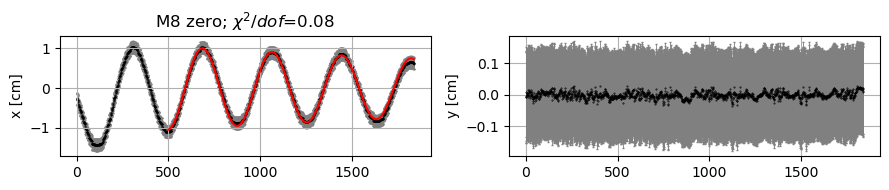

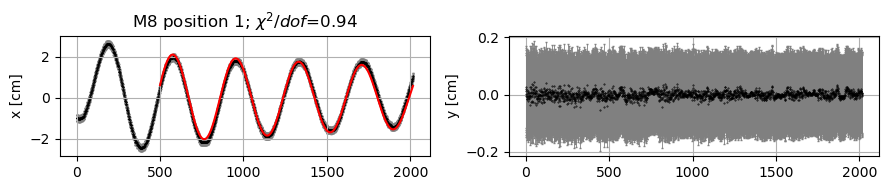

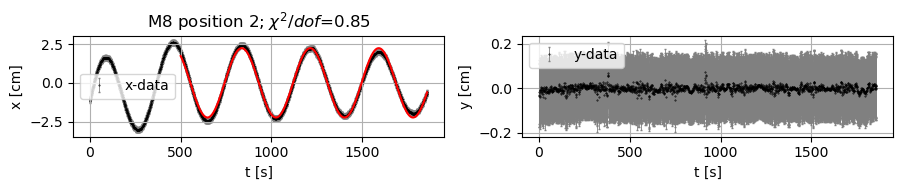

In [24]:
theta0 = fit(*np.loadtxt('m8/m8_p0.txt', skiprows=2, unpack=True), 'M8 zero', cutoff=500, plot=True)[4]
theta1 = fit(*np.loadtxt('m8/m8_p1_r4.txt', skiprows=2, unpack=True), 'M8 position 1', cutoff=500, plot=True)[4]
theta2 = fit(*np.loadtxt('m8/m8_p2_r4.txt', skiprows=2, unpack=True), 'M8 position 2',xlabel=True, cutoff=500, plot=True)[4]

R4 = 0.068

delta_r = 0.0
r = unp.uarray( R4  + delta_r, 0.003) 

conversion_factor =conversion(h1,h2)
print('G12 =',G_12(r, theta1, theta2, T, conversion_factor)) # *2 for G01,2 
print('G01 =',G_12(r, theta1, theta0, T, conversion_factor)*2)
print('G02 =',G_12(r, theta0, theta2, T, conversion_factor)*2)

print(theta0)
print(theta1)
print(theta2)